In [52]:
import pandas as pd
from geopy.geocoders import Nominatim
import folium
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

In [53]:
df = pd.read_csv('../Datasets/My_method_Data/EntireBoulderWithWeather.csv')
df.shape

(69061, 27)

### **Mapping Charging Points in Boulder, Colorado, USA**

In [54]:
# Create a geocoder
geolocator = Nominatim(user_agent="my_geocoder")

# List of addresses
addresses = (df['Address'].unique())

# Dictionary to store address and its coordinates
address_coordinates = {}

# Iterate through each address and geocode it
for address in addresses:
    location = geolocator.geocode(address + ", Boulder, CO")
    if location:
        address_coordinates[address] = (location.latitude, location.longitude)
    else:
        print(f"Coordinates for {address} could not be found.")

Coordinates for 1100 Walnut could not be found.


In [55]:
# Add the coordinates for '1100 Walnut' manually
# Source: https://developer.mapquest.com/documentation/tools/latitude-longitude-finder/
address_coordinates['1100 Walnut'] = (40.01664, -105.28078)

# Create a map centered around Boulder, CO
map_boulder = folium.Map(location=[40.0150, -105.2705], zoom_start=15)

# Add markers for each address
for address, coordinates in address_coordinates.items():
    folium.Marker(location=coordinates, popup=address).add_to(map_boulder)

map_boulder

In [56]:
daily = pd.read_csv('../Datasets/paper_data/Boulder_Daily.csv').drop(columns='Unnamed: 0')
daily.set_index('Date', inplace=True)
weekly = pd.read_csv('../Datasets/paper_data/Boulder_Weekly.csv').drop(columns='Unnamed: 0')
monthly = pd.read_csv('../Datasets/paper_data/Boulder_Monthly.csv').drop(columns='Unnamed: 0')

In [57]:
daily.head()

,Energy__kWh_,Weekday,Month,Minimum T,Maximum T,Snow,Precipitation,Year
Date,,,,,,,,
2018-01-01,6.504,Monday,January,12,30,0.0,0.0,2018
2018-01-02,17.527,Tuesday,January,24,92,0.0,0.0,2018
2018-01-03,11.227,Wednesday,January,60,150,0.0,0.0,2018
2018-01-04,49.748,Thursday,January,144,312,0.0,0.0,2018
2018-01-05,2.956,Friday,January,50,124,0.0,0.0,2018


In [58]:
weekly.head()

,Energy__kWh_,Minimum T,Maximum T,Snow,Precipitation,Year,Month_num,Week_num,Date
0,6.303917,24.583333,53.666667,0.000000,0.000000,2018,1,1,2018-01-01
1,7.051590,29.743590,54.102564,0.000000,0.052103,2018,1,2,2018-01-08
2,7.220676,21.864865,55.486486,10.915135,0.961081,2018,1,3,2018-01-15
3,6.326153,22.444444,48.916667,0.000000,0.000000,2018,1,4,2018-01-22
4,5.125958,27.375000,60.666667,0.000000,0.000000,2018,1,5,2018-01-29


In [59]:
monthly.head()

,Energy__kWh_,Month,Minimum T,Maximum T,Snow,Precipitation,Year,Month_num,Date
0,6.489679,January,24.653061,53.209184,2.060510,0.191796,2018,1,2018-01-01
1,7.982793,February,19.506803,45.901361,12.316063,0.698457,2018,2,2018-02-01
2,7.275274,March,29.423729,58.858757,4.397285,1.650282,2018,3,2018-03-01
3,7.506191,April,33.666667,65.052874,5.135063,1.099154,2018,4,2018-04-01
4,7.422334,May,45.959930,74.139373,0.000000,3.438589,2018,5,2018-05-01


### **Visualizing the Distribution of Charging Demand (Daily, Weekly, Monthly)**

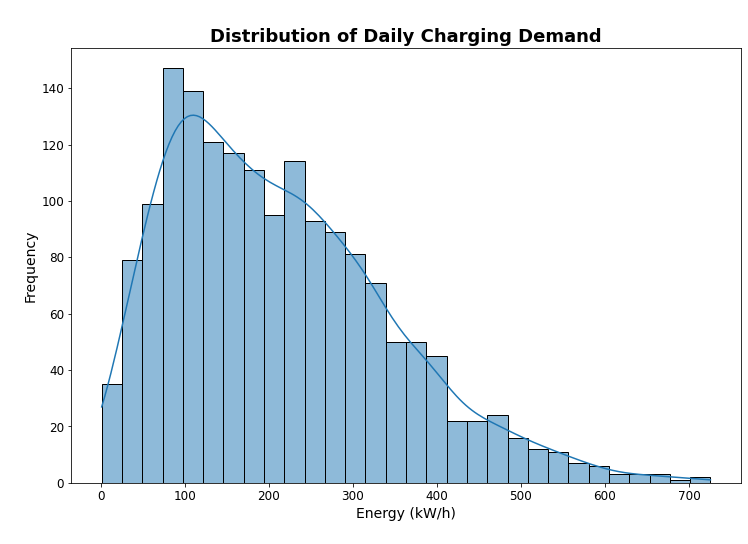

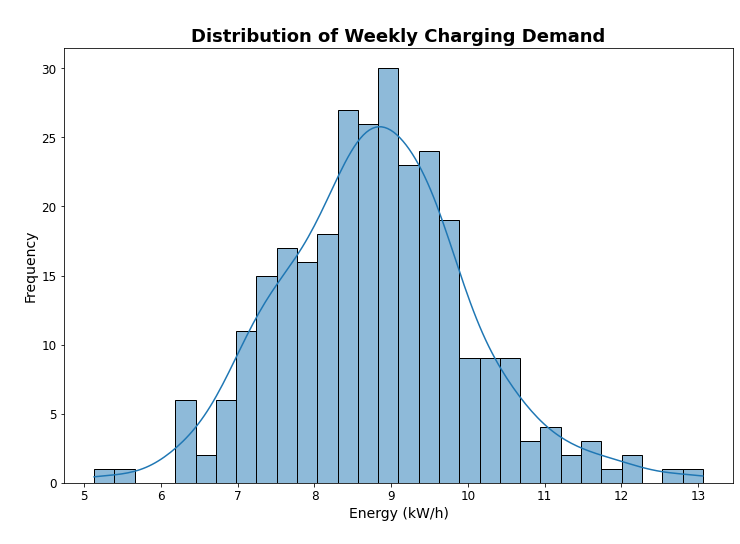

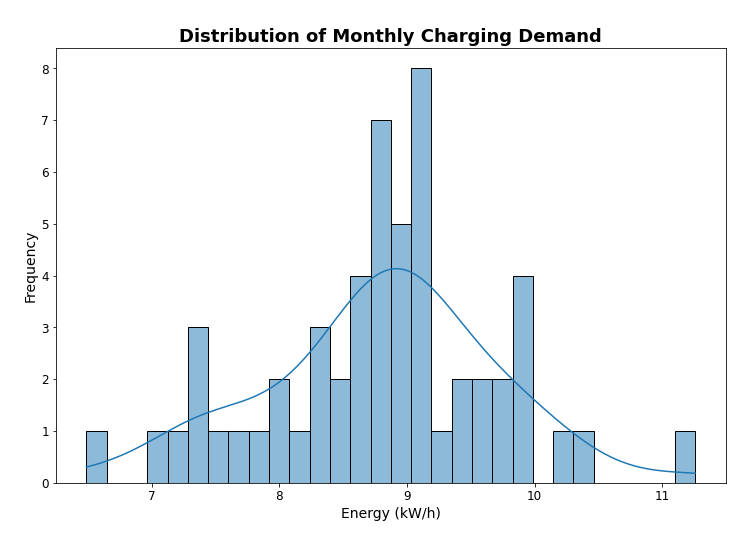

In [60]:
# Visualize the distribution of target variable (Energy_kWh)
plt.figure(figsize=(12, 8))
sns.histplot(daily['Energy__kWh_'], bins=30, kde=True)
plt.title('\nDistribution of Daily Charging Demand', fontsize=18, fontweight='bold')
plt.xlabel('Energy (kW/h)\n', fontsize=14)
plt.ylabel('\nFrequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Visualize the distribution of target variable (Energy_kWh)
plt.figure(figsize=(12, 8))
sns.histplot(weekly['Energy__kWh_'], bins=30, kde=True)
plt.title('\nDistribution of Weekly Charging Demand', fontsize=18, fontweight='bold')
plt.xlabel('Energy (kW/h)\n', fontsize=14)
plt.ylabel('\nFrequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


# Visualize the distribution of target variable (Energy_kWh)
plt.figure(figsize=(12, 8))
sns.histplot(monthly['Energy__kWh_'], bins=30, kde=True)
plt.title('\nDistribution of Monthly Charging Demand', fontsize=18, fontweight='bold')
plt.xlabel('Energy (kW/h)\n', fontsize=14)
plt.ylabel('\nFrequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### **Seasonal and Weekly Patterns in Energy Consumption**

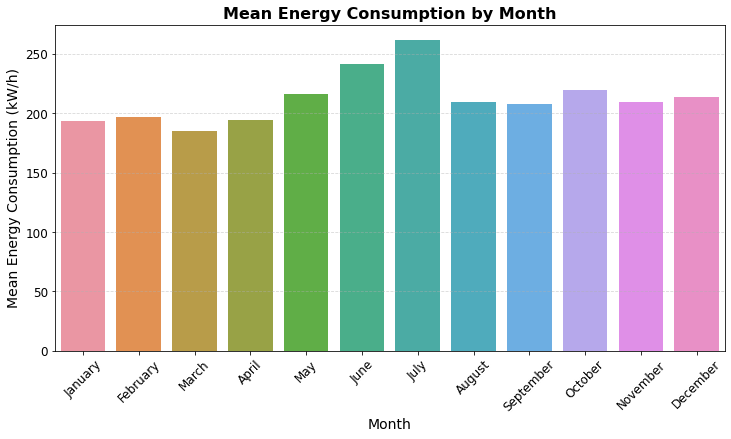

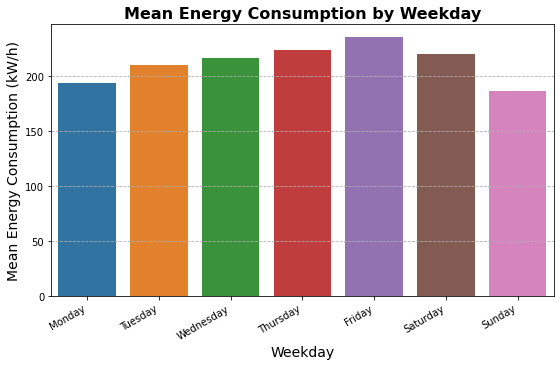

In [61]:
# Seasonal Patterns
monthly_energy = daily.groupby('Month')['Energy__kWh_'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x='Month', y='Energy__kWh_', data=monthly_energy, order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.title('Mean Energy Consumption by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Mean Energy Consumption (kW/h)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

weekday_energy = daily.groupby('Weekday')['Energy__kWh_'].mean().reset_index()
plt.figure(figsize=(9,5))
sns.barplot(x='Weekday', y='Energy__kWh_', data=weekday_energy, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Mean Energy Consumption by Weekday', fontsize=16, fontweight='bold')
plt.xlabel('Weekday', fontsize=14)
plt.ylabel('Mean Energy Consumption (kW/h)', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', linestyle='--')

### **Outlier Detection and Visualization of Daily Charging Demand using the IQR Method**

In [64]:
# Outlier Detection using IQR method
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers

# Identify outliers in 'Energy__kWh_'
outliers = detect_outliers_iqr(daily['Energy__kWh_'])
print("Number of records on DataFrame:", len(daily))
print("Number of outliers:", outliers.sum())
print("Outlier Dates:", daily[outliers].index.tolist())

Number of records on DataFrame: 1668
Number of outliers: 20
Outlier Dates: [Timestamp('2022-03-19 00:00:00'), Timestamp('2022-04-09 00:00:00'), Timestamp('2022-04-18 00:00:00'), Timestamp('2022-05-06 00:00:00'), Timestamp('2022-05-13 00:00:00'), Timestamp('2022-06-02 00:00:00'), Timestamp('2022-06-14 00:00:00'), Timestamp('2022-06-15 00:00:00'), Timestamp('2022-06-18 00:00:00'), Timestamp('2022-06-22 00:00:00'), Timestamp('2022-06-25 00:00:00'), Timestamp('2022-06-28 00:00:00'), Timestamp('2022-06-29 00:00:00'), Timestamp('2022-07-12 00:00:00'), Timestamp('2022-07-16 00:00:00'), Timestamp('2022-07-17 00:00:00'), Timestamp('2022-07-22 00:00:00'), Timestamp('2022-07-23 00:00:00'), Timestamp('2022-07-25 00:00:00'), Timestamp('2022-07-30 00:00:00')]


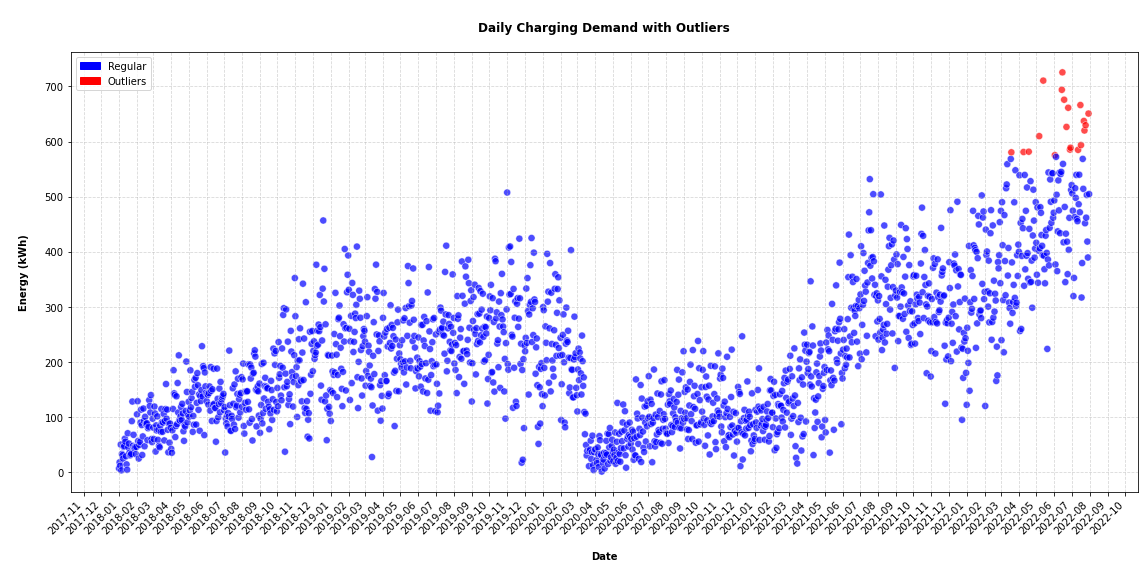

In [65]:
# Create legend handles
normal_patch = mpatches.Patch(color='blue', label='Regular')
outlier_patch = mpatches.Patch(color='red', label='Outliers')


# Set index to datetime format
daily.index = pd.to_datetime(daily.index)

# Plot energy column with outliers highlighted
plt.figure(figsize=(16, 8))
sns.scatterplot(data=daily, x=daily.index, y='Energy__kWh_', hue=outliers, palette={True: 'red', False: 'blue'}, legend=False, marker='o', s=50, alpha=0.7)
plt.title('\nDaily Charging Demand with Outliers\n', fontweight='bold')
plt.xlabel('\nDate', fontweight='bold')
plt.ylabel('\nEnergy (kWh)\n', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(handles=[normal_patch, outlier_patch], loc='upper left')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

In [66]:
daily.loc[outliers, daily.columns != 'Year']

,Energy__kWh_,Weekday,Month,Minimum T,Maximum T,Snow,Precipitation
Date,,,,,,,
2022-03-19,580.385,Saturday,March,1624,3480,0.0,0.00000
2022-04-09,580.967,Saturday,April,2970,5148,0.0,0.00000
2022-04-18,581.507,Monday,April,1200,2950,0.0,0.00000
2022-05-06,609.761,Friday,May,2852,5022,0.0,0.00000
2022-05-13,710.560,Friday,May,2438,3975,0.0,0.00000
2022-06-02,575.226,Thursday,June,1755,3105,0.0,0.00000
2022-06-14,693.889,Tuesday,June,2756,4770,0.0,0.00000
2022-06-15,725.552,Wednesday,June,2835,5481,0.0,0.00000
2022-06-18,675.901,Saturday,June,3843,5670,0.0,15.84198


In [67]:
daily.loc[outliers, daily.columns == 'Energy__kWh_']

,Energy__kWh_
Date,
2022-03-19,580.385
2022-04-09,580.967
2022-04-18,581.507
2022-05-06,609.761
2022-05-13,710.560
2022-06-02,575.226
2022-06-14,693.889
2022-06-15,725.552
2022-06-18,675.901


### **Time Series Decomposition and Anomaly Detection in Weekly Energy Consumption**

In [82]:
# Time Series Decomposition
weekly = pd.read_csv('../Datasets/paper_data/Boulder_Weekly.csv').drop(columns='Unnamed: 0')
weekly.set_index('Date', inplace=True)
weekly.sort_index(inplace=True)
decomposition = seasonal_decompose(weekly['Energy__kWh_'], model='additive', period=7)

    Visualizing Weekly Energy Consumption and Trend

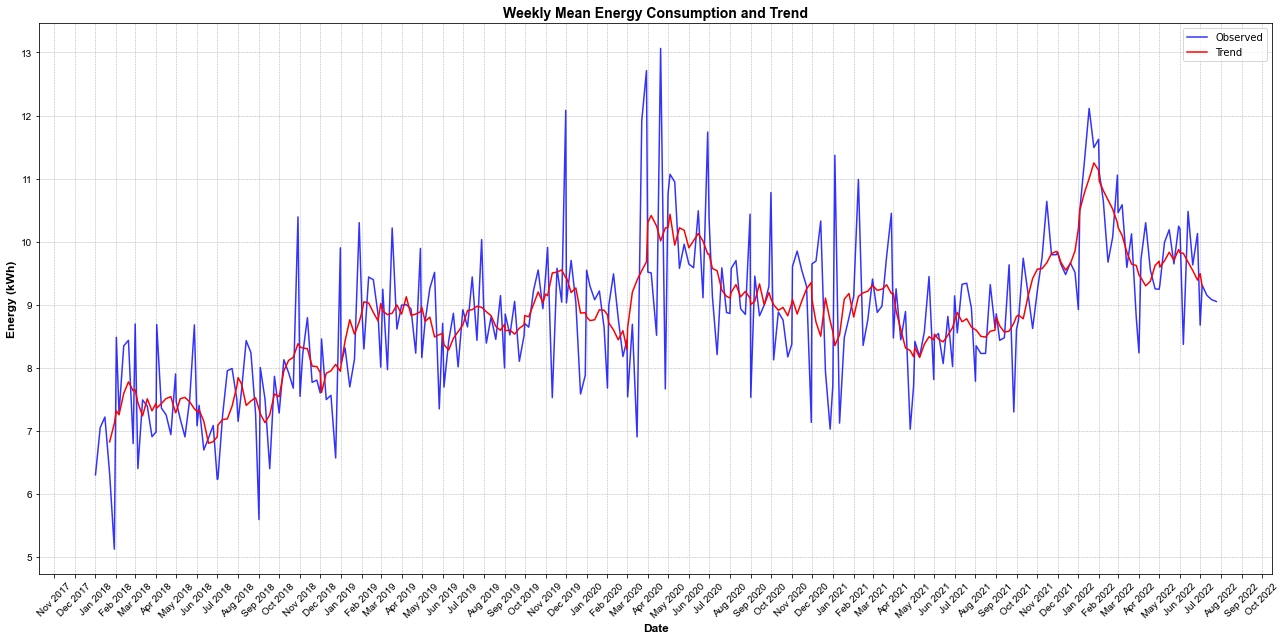

In [77]:
# Make the indexes a datetime
weekly.index = pd.to_datetime(weekly.index)

plt.figure(figsize=(18, 9))  # Adjust the figure size
plt.plot(weekly.index, decomposition.observed, label='Observed', linestyle='-', color='blue', alpha=0.8)
plt.plot(weekly.index, decomposition.trend, label='Trend', linestyle='-', color='red')

# Set major ticks to be monthly and minor ticks to be yearly
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_minor_locator(mdates.YearLocator())

plt.xticks(rotation=45, fontsize=10, fontname='Arial')  # Increase font size and set font family
plt.yticks(fontsize=10, fontname='Arial')  # Increase font size and set font family
plt.xlabel('Date', fontsize=12, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.ylabel('Energy (kWh)', fontsize=12, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.title('Weekly Mean Energy Consumption and Trend', fontsize=14, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.legend(fontsize=10)  # Increase font size for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines with a dashed style

plt.tight_layout()  # Adjust layout to prevent overlapping elements
plt.show()


    Visualizing Seasonal and Residual Components of Energy Consumption

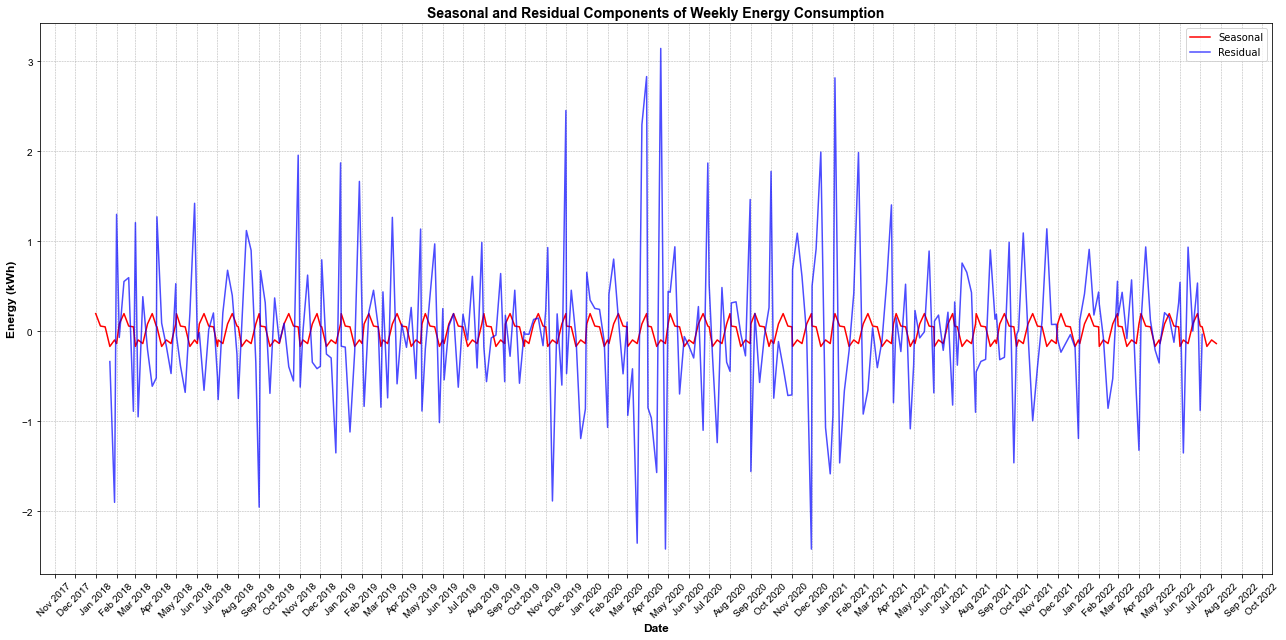

In [78]:
plt.figure(figsize=(18, 9))  # Adjust the figure size

# Plot seasonal component
plt.plot(weekly.index, decomposition.seasonal, label='Seasonal', linestyle='-', color='red')

# Plot residual component
plt.plot(weekly.index, decomposition.resid, label='Residual', linestyle='-', color='blue', alpha=0.7)

# Set major ticks to be monthly and minor ticks to be yearly
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_minor_locator(mdates.YearLocator())

plt.xticks(rotation=45, fontsize=10, fontname='Arial')  # Increase font size and set font family
plt.yticks(fontsize=10, fontname='Arial')  # Increase font size and set font family
plt.xlabel('Date', fontsize=12, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.ylabel('Energy (kWh)', fontsize=12, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.title('Seasonal and Residual Components of Weekly Energy Consumption', fontsize=14, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.legend(fontsize=10)  # Increase font size for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines with a dashed style

plt.tight_layout()  # Adjust layout to prevent overlapping elements
plt.show()


    Anomaly Detection in Weekly Energy Consumption Residuals

In [83]:
# Anomaly Detection
residuals = decomposition.resid
anomalies = weekly[(residuals > residuals.mean() + 2 * residuals.std()) | (residuals < residuals.mean() - 2 * residuals.std())]
print("Anomalous Days:")
anomalies

Anomalous Days:


,Energy__kWh_,Minimum T,Maximum T,Snow,Precipitation,Year,Month_num,Week_num
Date,,,,,,,,
2018-01-29,5.125958,27.375000,60.666667,0.000000,0.000000,2018,1,5
2018-09-01,5.595600,52.400000,80.466667,0.000000,0.117348,2018,9,35
2018-10-29,10.393186,37.728571,63.585714,2.721429,2.532743,2018,10,44
2018-12-31,9.903267,9.000000,42.000000,66.040000,3.302000,2018,12,1
2019-01-28,10.302054,13.238462,44.984615,13.286154,0.664308,2019,1,5
2019-11-11,7.527230,27.275510,60.734694,7.710714,0.418582,2019,11,46
2019-12-01,12.082789,13.000000,36.000000,0.000000,0.000000,2019,12,48
2020-03-16,6.903917,30.250000,56.250000,0.000000,0.105833,2020,3,12
2020-03-23,11.923150,31.250000,57.450000,5.588000,1.155319,2020,3,13


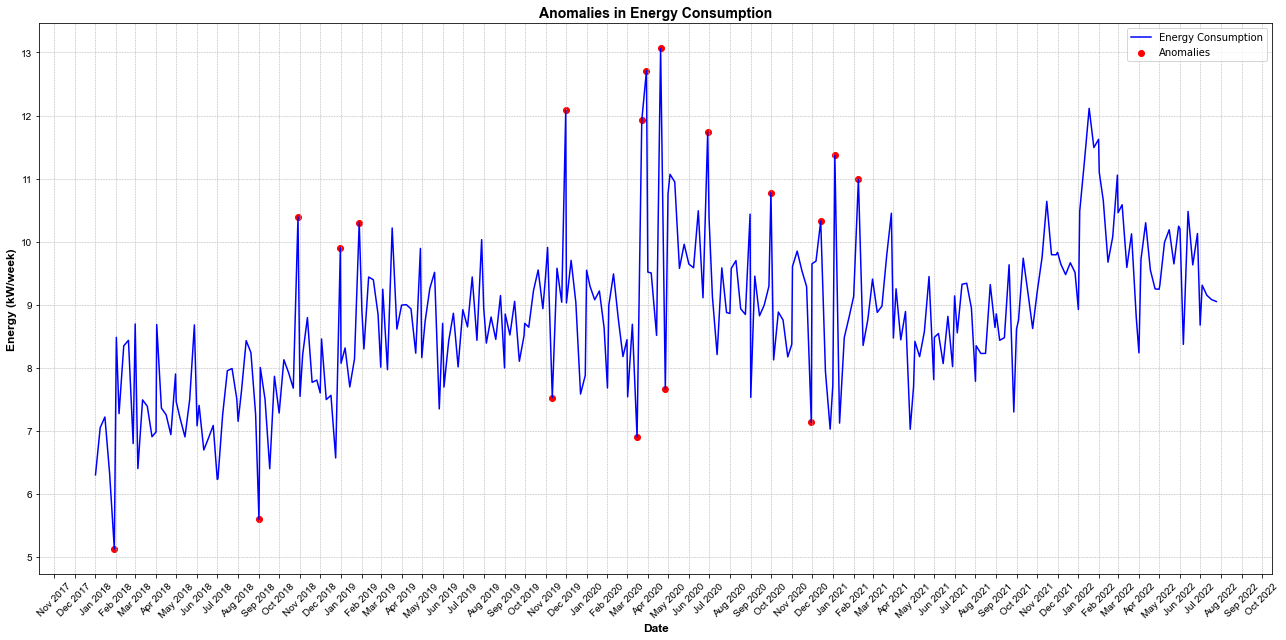

In [84]:
# Visualizing the anolamies
plt.figure(figsize=(18, 9))  # Adjust the figure size

# Make the indexes a datetime
weekly.index = pd.to_datetime(weekly.index)

# Plot seasonal component
plt.plot(weekly.index, weekly['Energy__kWh_'], label='Energy Consumption', linestyle='-', color='Blue')

# Plot residual component
plt.scatter(anomalies.index, anomalies['Energy__kWh_'], label='Anomalies', color='red')

# Set major ticks to be monthly and minor ticks to be yearly
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_minor_locator(mdates.YearLocator())

plt.xticks(rotation=45, fontsize=10, fontname='Arial')  # Increase font size and set font family
plt.yticks(fontsize=10, fontname='Arial')  # Increase font size and set font family
plt.xlabel('Date', fontsize=12, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.ylabel('Energy (kW/week)', fontsize=12, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.title('Anomalies in Energy Consumption', fontsize=14, fontname='Arial', fontweight='bold')  # Increase font size, set font family, and font weight
plt.legend(fontsize=10)  # Increase font size for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines with a dashed style

plt.tight_layout()  # Adjust layout to prevent overlapping elements
plt.show()
